# Credit Scoring
## Home Credit Default Risk

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook applies the trained LightGBM Tuned model from `Scorecard_Modelling.ipynb` to generate credit scores for new loan applicants in `application_test.csv`. The same preprocessing pipeline used during model training is applied to ensure consistency between training and scoring.

---

## 🎯 Objectives
- Load and preprocess `application_test.csv` using the same pipeline as training data
- Generate default probability scores for each applicant
- Assign risk tiers based on probability thresholds
- Export the final credit scoring results

---

## 🔍 Analysis Scope
The approach includes:
- Loading all raw test datasets and applying the same aggregation pipeline
- Merging all supplementary tables to the test main table
- Applying the same cleaning, imputation, and feature engineering steps
- Generating probability scores and risk tier classification
- Saving the final scoring output

---

## 🛠 Tools & Libraries
- Python
- Pandas
- NumPy
- Joblib
- LightGBM

---

## 📊 Output
The output of this notebook will serve as:
- A credit scoring file containing `SK_ID_CURR`, default probability, and risk tier for each applicant
- Input for business decision making on loan approval and terms
- A documented and reproducible scoring pipeline for production use

# Importing Library

In [1]:
# Installation Library
!pip install seaborn scikit-learn lightgbm xgboost catboost shap imbalanced-learn 


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install optuna
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import joblib

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import shap

In [4]:
# Hyperparameter Tunning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Importing Dataset

In [5]:
# Load test dataset
application_test_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_test.csv'
df_test = pd.read_csv(application_test_path)

# Load supplementary datasets
bureau_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau.csv'
df_bureau = pd.read_csv(bureau_path)

bureau_balance_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\bureau_balance.csv'
df_bureau_balance = pd.read_csv(bureau_balance_path)

previous_application_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\previous_application.csv'
df_prev = pd.read_csv(previous_application_path)

pos_cash_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\POS_CASH_balance.csv'
df_pos = pd.read_csv(pos_cash_path)

credit_card_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\credit_card_balance.csv'
df_cc = pd.read_csv(credit_card_path)

installments_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\installments_payments.csv'
df_installments = pd.read_csv(installments_path)

print(f"application_test shape : {df_test.shape}")
print(f"bureau shape           : {df_bureau.shape}")
print(f"bureau_balance shape   : {df_bureau_balance.shape}")
print(f"previous_application   : {df_prev.shape}")
print(f"POS_CASH_balance shape : {df_pos.shape}")
print(f"credit_card_balance    : {df_cc.shape}")
print(f"installments_payments  : {df_installments.shape}")

application_test shape : (48744, 121)
bureau shape           : (1716428, 17)
bureau_balance shape   : (27299925, 3)
previous_application   : (1670214, 37)
POS_CASH_balance shape : (10001358, 8)
credit_card_balance    : (3840312, 23)
installments_payments  : (13605401, 8)


# Load trained model

In [6]:
model_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\lgbm_tuned.pkl'
lgbm_tuned = joblib.load(model_path)
print("Model loaded successfully!")

Model loaded successfully!


# 1. Preprocessing Pipeline

This section applies the same preprocessing pipeline used during model training to ensure consistency between training and scoring data. All aggregation, merging, cleaning, and feature engineering steps are replicated exactly.

## 1.1 Aggregation

### 1.1.1 Bureau Balance Aggregation

In [7]:
# Bureau Balance Aggregation
status_map = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
df_bureau_balance['STATUS_NUMERIC'] = df_bureau_balance['STATUS'].map(status_map)

df_bb_agg = df_bureau_balance.groupby('SK_ID_BUREAU').agg(
    BB_COUNT=('MONTHS_BALANCE', 'count'),
    BB_MONTHS_MIN=('MONTHS_BALANCE', 'min'),
    BB_STATUS_MAX=('STATUS_NUMERIC', 'max'),
    BB_STATUS_MEAN=('STATUS_NUMERIC', 'mean'),
    BB_COUNT_STATUS_C=('STATUS', lambda x: (x == 'C').sum()),
    BB_COUNT_STATUS_0=('STATUS', lambda x: (x == '0').sum()),
    BB_COUNT_STATUS_X=('STATUS', lambda x: (x == 'X').sum()),
    BB_COUNT_DELINQUENT=('STATUS', lambda x: x.isin(['1', '2', '3', '4', '5']).sum()),
).reset_index()

df_bb_agg['BB_PROP_DELINQUENT'] = (df_bb_agg['BB_COUNT_DELINQUENT'] / df_bb_agg['BB_COUNT']).round(4)
df_bb_agg['BB_PROP_STATUS_C'] = (df_bb_agg['BB_COUNT_STATUS_C'] / df_bb_agg['BB_COUNT']).round(4)

# Bureau Aggregation
df_bureau_enriched = df_bureau.merge(df_bb_agg, on='SK_ID_BUREAU', how='left')

df_bureau_agg = df_bureau_enriched.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BUREAU_DAYS_CREDIT_UPDATE_MEAN=('DAYS_CREDIT_UPDATE', 'mean'),
    BUREAU_DAYS_CREDIT_ENDDATE_MEAN=('DAYS_CREDIT_ENDDATE', 'mean'),
    BUREAU_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN=('AMT_CREDIT_MAX_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_AMT_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_CREDIT_SUM_MAX=('AMT_CREDIT_SUM', 'max'),
    BUREAU_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_AMT_CREDIT_SUM_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN=('AMT_CREDIT_SUM_LIMIT', 'mean'),
    BUREAU_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    BUREAU_AMT_ANNUITY_MAX=('AMT_ANNUITY', 'max'),
    BUREAU_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_ACTIVE_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_BAD_DEBT_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Bad debt').sum()),
    BUREAU_SOLD_COUNT=('CREDIT_ACTIVE', lambda x: (x == 'Sold').sum()),
    BUREAU_CONSUMER_CREDIT_COUNT=('CREDIT_TYPE', lambda x: (x == 'Consumer credit').sum()),
    BUREAU_CREDIT_CARD_COUNT=('CREDIT_TYPE', lambda x: (x == 'Credit card').sum()),
    BUREAU_BB_COUNT_MEAN=('BB_COUNT', 'mean'),
    BUREAU_BB_MONTHS_MIN=('BB_MONTHS_MIN', 'min'),
    BUREAU_BB_STATUS_MAX=('BB_STATUS_MAX', 'max'),
    BUREAU_BB_STATUS_MEAN=('BB_STATUS_MEAN', 'mean'),
    BUREAU_BB_PROP_DELINQUENT_MEAN=('BB_PROP_DELINQUENT', 'mean'),
    BUREAU_BB_PROP_DELINQUENT_MAX=('BB_PROP_DELINQUENT', 'max'),
    BUREAU_BB_PROP_STATUS_C_MEAN=('BB_PROP_STATUS_C', 'mean'),
).reset_index()

df_bureau_agg['BUREAU_PROP_ACTIVE'] = (df_bureau_agg['BUREAU_ACTIVE_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_PROP_CLOSED'] = (df_bureau_agg['BUREAU_CLOSED_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_PROP_BAD_DEBT'] = (df_bureau_agg['BUREAU_BAD_DEBT_COUNT'] / df_bureau_agg['BUREAU_COUNT']).round(4)
df_bureau_agg['BUREAU_HAS_BAD_DEBT'] = (df_bureau_agg['BUREAU_BAD_DEBT_COUNT'] >= 1).astype(int)
df_bureau_agg['BUREAU_HAS_DELINQUENT'] = (df_bureau_agg['BUREAU_BB_STATUS_MAX'] >= 1).astype(int)

print(f"Bureau aggregation completed: {df_bureau_agg.shape}")

Bureau aggregation completed: (305811, 39)


### 1.1.2 Previous Application Aggregation

In [8]:
df_prev_agg = df_prev.groupby('SK_ID_CURR').agg(
    PREV_COUNT=('SK_ID_PREV', 'count'),
    PREV_DAYS_DECISION_MEAN=('DAYS_DECISION', 'mean'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
    PREV_DAYS_DECISION_MAX=('DAYS_DECISION', 'max'),
    PREV_AMT_ANNUITY_MEAN=('AMT_ANNUITY', 'mean'),
    PREV_AMT_ANNUITY_MAX=('AMT_ANNUITY', 'max'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_AMT_APPLICATION_SUM=('AMT_APPLICATION', 'sum'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_CREDIT_SUM=('AMT_CREDIT', 'sum'),
    PREV_AMT_DOWN_PAYMENT_MEAN=('AMT_DOWN_PAYMENT', 'mean'),
    PREV_AMT_GOODS_PRICE_MEAN=('AMT_GOODS_PRICE', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_CNT_PAYMENT_SUM=('CNT_PAYMENT', 'sum'),
    PREV_APPROVED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_UNUSED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Unused offer').sum()),
    PREV_CASH_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Cash loans').sum()),
    PREV_CONSUMER_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Consumer loans').sum()),
    PREV_REVOLVING_COUNT=('NAME_CONTRACT_TYPE', lambda x: (x == 'Revolving loans').sum()),
    PREV_REPEATER_COUNT=('NAME_CLIENT_TYPE', lambda x: (x == 'Repeater').sum()),
    PREV_NEW_COUNT=('NAME_CLIENT_TYPE', lambda x: (x == 'New').sum()),
    PREV_YIELD_HIGH_COUNT=('NAME_YIELD_GROUP', lambda x: (x == 'high').sum()),
    PREV_YIELD_LOW_ACTION_COUNT=('NAME_YIELD_GROUP', lambda x: (x == 'low_action').sum()),
    PREV_CHANNEL_AP_COUNT=('CHANNEL_TYPE', lambda x: (x == 'AP+ (Cash loan)').sum()),
    PREV_RATE_DOWN_PAYMENT_MEAN=('RATE_DOWN_PAYMENT', 'mean'),
).reset_index()

df_prev_agg['PREV_PROP_APPROVED'] = (df_prev_agg['PREV_APPROVED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_PROP_REFUSED'] = (df_prev_agg['PREV_REFUSED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_PROP_CANCELED'] = (df_prev_agg['PREV_CANCELED_COUNT'] / df_prev_agg['PREV_COUNT']).round(4)
df_prev_agg['PREV_CREDIT_TO_APPLICATION_RATIO'] = (
    df_prev_agg['PREV_AMT_CREDIT_MEAN'] / df_prev_agg['PREV_AMT_APPLICATION_MEAN']
).round(4)
df_prev_agg['PREV_HAS_REFUSED'] = (df_prev_agg['PREV_REFUSED_COUNT'] >= 1).astype(int)
df_prev_agg['PREV_HAS_REVOLVING'] = (df_prev_agg['PREV_REVOLVING_COUNT'] >= 1).astype(int)

print(f"Previous application aggregation completed: {df_prev_agg.shape}")

Previous application aggregation completed: (338857, 34)


### 1.1.3 POS CASH Balance Aggregation

In [9]:
df_pos_agg = df_pos.groupby('SK_ID_CURR').agg(
    POS_COUNT=('SK_ID_PREV', 'count'),
    POS_UNIQUE_LOANS=('SK_ID_PREV', 'nunique'),
    POS_MONTHS_BALANCE_MEAN=('MONTHS_BALANCE', 'mean'),
    POS_MONTHS_BALANCE_MIN=('MONTHS_BALANCE', 'min'),
    POS_CNT_INSTALMENT_MEAN=('CNT_INSTALMENT', 'mean'),
    POS_CNT_INSTALMENT_MAX=('CNT_INSTALMENT', 'max'),
    POS_CNT_INSTALMENT_FUTURE_MEAN=('CNT_INSTALMENT_FUTURE', 'mean'),
    POS_CNT_INSTALMENT_FUTURE_MAX=('CNT_INSTALMENT_FUTURE', 'max'),
    POS_SK_DPD_MEAN=('SK_DPD', 'mean'),
    POS_SK_DPD_MAX=('SK_DPD', 'max'),
    POS_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    POS_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
    POS_ACTIVE_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    POS_COMPLETED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    POS_DEMAND_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Demand').sum()),
    POS_AMORTIZED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Amortized debt').sum()),
    POS_RETURNED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Returned to the store').sum()),
).reset_index()

df_pos_agg['POS_PROP_ACTIVE'] = (df_pos_agg['POS_ACTIVE_COUNT'] / df_pos_agg['POS_COUNT']).round(4)
df_pos_agg['POS_PROP_COMPLETED'] = (df_pos_agg['POS_COMPLETED_COUNT'] / df_pos_agg['POS_COUNT']).round(4)
df_pos_agg['POS_HAS_DEMAND'] = (df_pos_agg['POS_DEMAND_COUNT'] >= 1).astype(int)
df_pos_agg['POS_HAS_AMORTIZED'] = (df_pos_agg['POS_AMORTIZED_COUNT'] >= 1).astype(int)
df_pos_agg['POS_INSTALMENT_COMPLETION_RATIO'] = (
    1 - (df_pos_agg['POS_CNT_INSTALMENT_FUTURE_MEAN'] / df_pos_agg['POS_CNT_INSTALMENT_MEAN'])
).round(4)

print(f"POS CASH balance aggregation completed: {df_pos_agg.shape}")

POS CASH balance aggregation completed: (337252, 23)


### 1.1.4 Credit Card Balance Aggregation

In [10]:
df_cc_agg = df_cc.groupby('SK_ID_CURR').agg(
    CC_COUNT=('SK_ID_PREV', 'count'),
    CC_UNIQUE_CARDS=('SK_ID_PREV', 'nunique'),
    CC_AMT_BALANCE_MEAN=('AMT_BALANCE', 'mean'),
    CC_AMT_BALANCE_MAX=('AMT_BALANCE', 'max'),
    CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
    CC_AMT_CREDIT_LIMIT_ACTUAL_MAX=('AMT_CREDIT_LIMIT_ACTUAL', 'max'),
    CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN=('AMT_PAYMENT_TOTAL_CURRENT', 'mean'),
    CC_AMT_PAYMENT_TOTAL_CURRENT_SUM=('AMT_PAYMENT_TOTAL_CURRENT', 'sum'),
    CC_AMT_INST_MIN_REGULARITY_MEAN=('AMT_INST_MIN_REGULARITY', 'mean'),
    CC_AMT_DRAWINGS_CURRENT_MEAN=('AMT_DRAWINGS_CURRENT', 'mean'),
    CC_AMT_DRAWINGS_CURRENT_SUM=('AMT_DRAWINGS_CURRENT', 'sum'),
    CC_AMT_DRAWINGS_ATM_CURRENT_MEAN=('AMT_DRAWINGS_ATM_CURRENT', 'mean'),
    CC_CNT_DRAWINGS_CURRENT_MEAN=('CNT_DRAWINGS_CURRENT', 'mean'),
    CC_CNT_INSTALMENT_MATURE_CUM_MEAN=('CNT_INSTALMENT_MATURE_CUM', 'mean'),
    CC_CNT_INSTALMENT_MATURE_CUM_MAX=('CNT_INSTALMENT_MATURE_CUM', 'max'),
    CC_SK_DPD_MEAN=('SK_DPD', 'mean'),
    CC_SK_DPD_MAX=('SK_DPD', 'max'),
    CC_SK_DPD_DEF_MEAN=('SK_DPD_DEF', 'mean'),
    CC_SK_DPD_DEF_MAX=('SK_DPD_DEF', 'max'),
    CC_ACTIVE_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
    CC_COMPLETED_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    CC_DEMAND_COUNT=('NAME_CONTRACT_STATUS', lambda x: (x == 'Demand').sum()),
).reset_index()

df_cc_agg['CC_PROP_ACTIVE'] = (df_cc_agg['CC_ACTIVE_COUNT'] / df_cc_agg['CC_COUNT']).round(4)
df_cc_agg['CC_PROP_COMPLETED'] = (df_cc_agg['CC_COMPLETED_COUNT'] / df_cc_agg['CC_COUNT']).round(4)
df_cc_agg['CC_HAS_DEMAND'] = (df_cc_agg['CC_DEMAND_COUNT'] >= 1).astype(int)
df_cc_agg['CC_UTILIZATION_RATIO'] = (
    df_cc_agg['CC_AMT_BALANCE_MEAN'] / df_cc_agg['CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN']
).round(4)

print(f"Credit card balance aggregation completed: {df_cc_agg.shape}")

Credit card balance aggregation completed: (103558, 27)


### 1.1.5 Installments Payments Aggregation

In [11]:
df_installments['DAYS_PAYMENT_DIFF'] = df_installments['DAYS_ENTRY_PAYMENT'] - df_installments['DAYS_INSTALMENT']
df_installments['AMT_PAYMENT_DIFF'] = df_installments['AMT_INSTALMENT'] - df_installments['AMT_PAYMENT']

df_inst_agg = df_installments.groupby('SK_ID_CURR').agg(
    INST_COUNT=('SK_ID_PREV', 'count'),
    INST_UNIQUE_LOANS=('SK_ID_PREV', 'nunique'),
    INST_NUM_INSTALMENT_NUMBER_MAX=('NUM_INSTALMENT_NUMBER', 'max'),
    INST_NUM_INSTALMENT_NUMBER_MEAN=('NUM_INSTALMENT_NUMBER', 'mean'),
    INST_DAYS_INSTALMENT_MEAN=('DAYS_INSTALMENT', 'mean'),
    INST_DAYS_INSTALMENT_MAX=('DAYS_INSTALMENT', 'max'),
    INST_DAYS_ENTRY_PAYMENT_MEAN=('DAYS_ENTRY_PAYMENT', 'mean'),
    INST_AMT_INSTALMENT_MEAN=('AMT_INSTALMENT', 'mean'),
    INST_AMT_INSTALMENT_SUM=('AMT_INSTALMENT', 'sum'),
    INST_AMT_PAYMENT_MEAN=('AMT_PAYMENT', 'mean'),
    INST_AMT_PAYMENT_SUM=('AMT_PAYMENT', 'sum'),
    INST_DAYS_PAYMENT_DIFF_MEAN=('DAYS_PAYMENT_DIFF', 'mean'),
    INST_DAYS_PAYMENT_DIFF_MAX=('DAYS_PAYMENT_DIFF', 'max'),
    INST_DAYS_PAYMENT_DIFF_MIN=('DAYS_PAYMENT_DIFF', 'min'),
    INST_AMT_PAYMENT_DIFF_MEAN=('AMT_PAYMENT_DIFF', 'mean'),
    INST_AMT_PAYMENT_DIFF_MAX=('AMT_PAYMENT_DIFF', 'max'),
    INST_AMT_PAYMENT_DIFF_SUM=('AMT_PAYMENT_DIFF', 'sum'),
).reset_index()

df_installments['IS_LATE'] = (df_installments['DAYS_PAYMENT_DIFF'] > 0).astype(int)
df_installments['IS_UNDERPAID'] = (df_installments['AMT_PAYMENT_DIFF'] > 0).astype(int)

late_agg = df_installments.groupby('SK_ID_CURR').agg(
    INST_LATE_COUNT=('IS_LATE', 'sum'),
    INST_UNDERPAID_COUNT=('IS_UNDERPAID', 'sum'),
).reset_index()

df_inst_agg = df_inst_agg.merge(late_agg, on='SK_ID_CURR', how='left')
df_inst_agg['INST_PROP_LATE'] = (df_inst_agg['INST_LATE_COUNT'] / df_inst_agg['INST_COUNT']).round(4)
df_inst_agg['INST_PROP_UNDERPAID'] = (df_inst_agg['INST_UNDERPAID_COUNT'] / df_inst_agg['INST_COUNT']).round(4)
df_inst_agg['INST_AMT_PAYMENT_RATIO'] = (
    df_inst_agg['INST_AMT_PAYMENT_SUM'] / df_inst_agg['INST_AMT_INSTALMENT_SUM']
).round(4)
df_inst_agg['INST_HAS_LATE'] = (df_inst_agg['INST_LATE_COUNT'] >= 1).astype(int)
df_inst_agg['INST_HAS_UNDERPAID'] = (df_inst_agg['INST_UNDERPAID_COUNT'] >= 1).astype(int)

print(f"Installments payments aggregation completed: {df_inst_agg.shape}")

Installments payments aggregation completed: (339587, 25)


## 1.2 Merging

In [12]:
# application_test as base
df_test_merged = df_test.copy()
print(f"Base: {df_test_merged.shape}")

Base: (48744, 121)


In [13]:
# Merge bureau aggregations
df_test_merged = df_test_merged.merge(df_bureau_agg, on='SK_ID_CURR', how='left')
print(f"After bureau merge: {df_test_merged.shape}")

After bureau merge: (48744, 159)


In [14]:
# Merge previous_application aggregations
df_test_merged = df_test_merged.merge(df_prev_agg, on='SK_ID_CURR', how='left')
print(f"After previous_application merge: {df_test_merged.shape}")

After previous_application merge: (48744, 192)


In [15]:
# Merge POS_CASH_balance aggregations
df_test_merged = df_test_merged.merge(df_pos_agg, on='SK_ID_CURR', how='left')
print(f"After POS_CASH_balance merge: {df_test_merged.shape}")

After POS_CASH_balance merge: (48744, 214)


In [16]:
# Merge credit_card_balance aggregations
df_test_merged = df_test_merged.merge(df_cc_agg, on='SK_ID_CURR', how='left')
print(f"After credit_card_balance merge: {df_test_merged.shape}")

After credit_card_balance merge: (48744, 240)


In [17]:
# Merge installments_payments aggregations
df_test_merged = df_test_merged.merge(df_inst_agg, on='SK_ID_CURR', how='left')
print(f"After installments_payments merge: {df_test_merged.shape}")

After installments_payments merge: (48744, 264)


## 1.3 Cleaning & Feature Engineering

This section applies the same cleaning and feature engineering pipeline used during model training in `Data Cleaning and Handling.ipynb`. All decisions are based on findings from individual EDA notebooks.

The approach includes:
- **Dropping** irrelevant, redundant, and high-missing-rate features
- **Imputing** missing values per feature group based on domain context
- **Special handling** for anomalous encodings identified in EDA
- **Capping** outliers at 1st and 99th percentile
- **Engineering** derived features from domain knowledge

---

### 1.3.1 Feature Drop

**application_train:**
- `FLAG_MOBIL`, `FLAG_CONT_MOBILE`: near-constant features (>99% same value), no predictive signal
- `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE`: near-constant features (>98% same value)
- `AMT_GOODS_PRICE`: near-perfectly correlated with `AMT_CREDIT` (0.99)
- `CNT_FAM_MEMBERS`: near-perfectly correlated with `CNT_CHILDREN` (0.88)
- `_MODE` and `_MEDI` building variants: perfectly redundant with `_AVG` variants
- `AMT_RECEIVABLE_PRINCIPAL`, `AMT_TOTAL_RECEIVABLE`: perfectly correlated with `AMT_BALANCE` (1.00) from credit_card_balance
- `CC_AMT_DRAWINGS_ATM_CURRENT_MEAN`: missing rate > 80%

---

In [18]:
# Store SK_ID_CURR for output
sk_id_curr = df_test_merged['SK_ID_CURR'].copy()

# Drop irrelevant features
drop_cols = [
    'FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'HOUSETYPE_MODE', 'EMERGENCYSTATE_MODE',
    'AMT_GOODS_PRICE', 'CNT_FAM_MEMBERS',
    'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
    'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MODE',
    'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI',
    'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'APARTMENTS_MEDI',
    'AMT_RECEIVABLE_PRINCIPAL', 'AMT_TOTAL_RECEIVABLE',
    'CC_AMT_DRAWINGS_ATM_CURRENT_MEAN'
]
df_test_merged.drop(columns=[col for col in drop_cols if col in df_test_merged.columns], inplace=True)
print(f"Shape after drop: {df_test_merged.shape}")


Shape after drop: (48744, 229)


### 1.3.2 Missing Value Handling

**application_train features:**
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`: impute with **median** — strong predictors, random missingness
- `OWN_CAR_AGE`: impute with **0** — missing indicates no car ownership
- `AMT_ANNUITY`, `AMT_REQ_CREDIT_BUREAU_*`: impute with **median**
- `NAME_TYPE_SUITE`, `OCCUPATION_TYPE`, `FONDKAPREMONT_MODE`, `WALLSMATERIAL_MODE`: impute with **mode** — categorical features with low missing rate
- Building features (`_AVG`), `TOTALAREA_MODE`: impute with **median**
- Social circle features, `DAYS_LAST_PHONE_CHANGE`: impute with **median**

**bureau features (`BUREAU_*`):**
- All features: impute with **0** — missing indicates no bureau history for that applicant

**previous_application features (`PREV_*`):**
- All features: impute with **0** — missing indicates no previous application history

**POS_CASH_balance features (`POS_*`):**
- All features: impute with **0** — missing indicates no POS/cash loan history

**credit_card_balance features (`CC_*`):**
- All features: impute with **0** — missing indicates no credit card history (66.32% of applicants have no credit card records)

**installments_payments features (`INST_*`):**
- `INST_AMT_PAYMENT_RATIO`: impute with **1** — neutral value representing no payment history
- All other features: impute with **0** — missing indicates no installment history

---

In [19]:
# Missing value handling - application_train
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    df_test_merged[col] = df_test_merged[col].fillna(df_test_merged[col].median())

df_test_merged['OWN_CAR_AGE'] = df_test_merged['OWN_CAR_AGE'].fillna(0)
df_test_merged['AMT_ANNUITY'] = df_test_merged['AMT_ANNUITY'].fillna(df_test_merged['AMT_ANNUITY'].median())

for col in [c for c in df_test_merged.columns if c.startswith('AMT_REQ_CREDIT_BUREAU')]:
    df_test_merged[col] = df_test_merged[col].fillna(df_test_merged[col].median())

for col in ['NAME_TYPE_SUITE', 'OCCUPATION_TYPE', 'FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE']:
    if col in df_test_merged.columns:
        df_test_merged[col] = df_test_merged[col].fillna(df_test_merged[col].mode()[0])

for col in [c for c in df_test_merged.columns if c.endswith('_AVG')]:
    df_test_merged[col] = df_test_merged[col].fillna(df_test_merged[col].median())

df_test_merged['TOTALAREA_MODE'] = df_test_merged['TOTALAREA_MODE'].fillna(df_test_merged['TOTALAREA_MODE'].median())

for col in ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
            'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
            'DAYS_LAST_PHONE_CHANGE']:
    df_test_merged[col] = df_test_merged[col].fillna(df_test_merged[col].median())

In [20]:
# Missing value handling - supplementary tables
for col in [c for c in df_test_merged.columns if c.startswith('BUREAU_')]:
    df_test_merged[col] = df_test_merged[col].fillna(0)

for col in [c for c in df_test_merged.columns if c.startswith('PREV_')]:
    df_test_merged[col] = df_test_merged[col].fillna(0)

for col in [c for c in df_test_merged.columns if c.startswith('POS_')]:
    df_test_merged[col] = df_test_merged[col].fillna(0)

for col in [c for c in df_test_merged.columns if c.startswith('CC_')]:
    df_test_merged[col] = df_test_merged[col].fillna(0)

df_test_merged['INST_AMT_PAYMENT_RATIO'] = df_test_merged['INST_AMT_PAYMENT_RATIO'].fillna(1)
for col in [c for c in df_test_merged.columns if c.startswith('INST_')]:
    df_test_merged[col] = df_test_merged[col].fillna(0)

print(f"Total missing after imputation: {df_test_merged.isnull().sum().sum()}")


Total missing after imputation: 0


### 1.3.3 Special Handling

**application_train:**
- `DAYS_EMPLOYED = 365,243`: encoding anomaly for pensioners/unemployed, replace with **median**
- `CODE_GENDER = XNA`: only 4 records, replace with **mode**
- `NAME_FAMILY_STATUS = Unknown`: only 2 records, replace with **mode**
- `NAME_INCOME_TYPE` rare categories (Maternity leave, Student, Businessman): group into **Other**

---

In [21]:
# Special handling
df_test_merged['DAYS_EMPLOYED'] = df_test_merged['DAYS_EMPLOYED'].replace(365243, np.nan)
df_test_merged['DAYS_EMPLOYED'] = df_test_merged['DAYS_EMPLOYED'].fillna(df_test_merged['DAYS_EMPLOYED'].median())
df_test_merged['CODE_GENDER'] = df_test_merged['CODE_GENDER'].replace('XNA', df_test_merged['CODE_GENDER'].mode()[0])
df_test_merged['NAME_FAMILY_STATUS'] = df_test_merged['NAME_FAMILY_STATUS'].replace('Unknown', df_test_merged['NAME_FAMILY_STATUS'].mode()[0])
df_test_merged['NAME_INCOME_TYPE'] = df_test_merged['NAME_INCOME_TYPE'].replace(['Maternity leave', 'Student', 'Businessman'], 'Other')

### 1.3.4 Outlier Capping (1st - 99th Percentile)

**application_train:**
- `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`: heavily right-skewed with extreme outliers
- `OBS/DEF_30/60_CNT_SOCIAL_CIRCLE`: extreme outliers identified in EDA

**bureau features:**
- `BUREAU_AMT_CREDIT_SUM_*`, `BUREAU_AMT_CREDIT_MAX_OVERDUE_*`, `BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN`, `BUREAU_AMT_ANNUITY_MEAN`: extreme right-skewed distributions with outliers up to 585M

**previous_application features:**
- `PREV_AMT_CREDIT_*`, `PREV_AMT_APPLICATION_*`, `PREV_AMT_GOODS_PRICE_MEAN`: extreme outliers extending to 6.9M

**POS_CASH_balance features:**
- `POS_SK_DPD_*`: extreme outliers up to 4,231 days past due

**credit_card_balance features:**
- `CC_AMT_BALANCE_*`, `CC_SK_DPD_*`, `CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN`, `CC_UTILIZATION_RATIO`: extreme outliers and negative balance values

**installments_payments features:**
- `INST_AMT_INSTALMENT_MEAN`, `INST_AMT_PAYMENT_MEAN`, `INST_DAYS_PAYMENT_DIFF_MAX`, `INST_AMT_PAYMENT_DIFF_*`, `INST_AMT_PAYMENT_RATIO`: bilateral outliers identified in EDA

---

In [22]:
# Capping
cap_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
    'BUREAU_AMT_CREDIT_SUM_MEAN', 'BUREAU_AMT_CREDIT_SUM_SUM',
    'BUREAU_AMT_CREDIT_SUM_DEBT_MEAN', 'BUREAU_AMT_CREDIT_SUM_DEBT_SUM',
    'BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN', 'BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX',
    'BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN', 'BUREAU_AMT_ANNUITY_MEAN',
    'PREV_AMT_CREDIT_MEAN', 'PREV_AMT_CREDIT_SUM',
    'PREV_AMT_APPLICATION_MEAN', 'PREV_AMT_APPLICATION_SUM',
    'PREV_AMT_GOODS_PRICE_MEAN',
    'POS_SK_DPD_MEAN', 'POS_SK_DPD_MAX',
    'POS_SK_DPD_DEF_MEAN', 'POS_SK_DPD_DEF_MAX',
    'CC_AMT_BALANCE_MEAN', 'CC_AMT_BALANCE_MAX',
    'CC_SK_DPD_MEAN', 'CC_SK_DPD_MAX',
    'CC_SK_DPD_DEF_MEAN', 'CC_SK_DPD_DEF_MAX',
    'CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN', 'CC_UTILIZATION_RATIO',
    'INST_AMT_INSTALMENT_MEAN', 'INST_AMT_PAYMENT_MEAN',
    'INST_DAYS_PAYMENT_DIFF_MAX', 'INST_AMT_PAYMENT_DIFF_MEAN',
    'INST_AMT_PAYMENT_DIFF_MAX', 'INST_AMT_PAYMENT_RATIO',
]

for col in cap_cols:
    if col in df_test_merged.columns:
        p01 = df_test_merged[col].quantile(0.01)
        p99 = df_test_merged[col].quantile(0.99)
        df_test_merged[col] = df_test_merged[col].clip(lower=p01, upper=p99)

print("Special handling and capping completed.")

Special handling and capping completed.


### 1.3.5 Feature Engineering

**Missing Indicators:**
- `EXT_SOURCE_1_MISSING`, `EXT_SOURCE_3_MISSING`: high missing rate with predictive signal
- `OWN_CAR_AGE_MISSING`, `OCCUPATION_TYPE_MISSING`: missingness carries risk signal

**Ratio Features:**
- `CREDIT_TO_INCOME_RATIO`: debt burden relative to income
- `ANNUITY_TO_INCOME_RATIO`: monthly payment burden relative to income
- `CREDIT_TO_ANNUITY_RATIO`: proxy for loan term length
- `EMPLOYED_TO_AGE_RATIO`: employment stability relative to age

**Transformation Features:**
- `AGE_YEARS`: `DAYS_BIRTH` converted to years for interpretability
- `EMPLOYED_YEARS`: `DAYS_EMPLOYED` converted to years

**EXT_SOURCE Combinations:**
- `EXT_SOURCE_MEAN`: mean of three external scores
- `EXT_SOURCE_PROD`: product of three external scores, captures joint low-score effect

**Cross-Table Derived Features:**
- `INCOME_PER_PERSON`: income normalized by family size
- `BUREAU_INST_DELINQUENCY`: combined delinquency signal from bureau and installments

In [23]:
# Missing indicators
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'OWN_CAR_AGE', 'OCCUPATION_TYPE']:
    if col in df_test_merged.columns:
        df_test_merged[f'{col}_MISSING'] = df_test_merged[col].isnull().astype(int)

# Ratio features
df_test_merged['CREDIT_TO_INCOME_RATIO'] = (df_test_merged['AMT_CREDIT'] / df_test_merged['AMT_INCOME_TOTAL']).round(4)
df_test_merged['ANNUITY_TO_INCOME_RATIO'] = (df_test_merged['AMT_ANNUITY'] / df_test_merged['AMT_INCOME_TOTAL']).round(4)
df_test_merged['CREDIT_TO_ANNUITY_RATIO'] = (df_test_merged['AMT_CREDIT'] / df_test_merged['AMT_ANNUITY']).round(4)
df_test_merged['AGE_YEARS'] = (df_test_merged['DAYS_BIRTH'] / -365).round(2)
df_test_merged['EMPLOYED_YEARS'] = (df_test_merged['DAYS_EMPLOYED'] / -365).round(2)
df_test_merged['EMPLOYED_TO_AGE_RATIO'] = (df_test_merged['EMPLOYED_YEARS'] / df_test_merged['AGE_YEARS']).round(4)
df_test_merged['EXT_SOURCE_MEAN'] = df_test_merged[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1).round(4)
df_test_merged['EXT_SOURCE_PROD'] = (df_test_merged['EXT_SOURCE_1'] * df_test_merged['EXT_SOURCE_2'] * df_test_merged['EXT_SOURCE_3']).round(4)
df_test_merged['INCOME_PER_PERSON'] = (df_test_merged['AMT_INCOME_TOTAL'] / df_test_merged['CNT_CHILDREN'].replace(0, 1)).round(4)
df_test_merged['BUREAU_INST_DELINQUENCY'] = (df_test_merged['BUREAU_BB_PROP_DELINQUENT_MEAN'] + df_test_merged['INST_PROP_LATE']).round(4)

# Fix infinity values
for col in df_test_merged.select_dtypes(include=['float64', 'int64']).columns:
    df_test_merged[col] = df_test_merged[col].replace([np.inf, -np.inf], np.nan).fillna(0)

# Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df_test_merged.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'SK_ID_CURR']
for col in cat_cols:
    df_test_merged[col] = le.fit_transform(df_test_merged[col].astype(str))

print(f"Feature engineering completed.")
print(f"Final shape: {df_test_merged.shape}")
print(f"Total missing: {df_test_merged.isnull().sum().sum()}")

Feature engineering completed.
Final shape: (48744, 243)
Total missing: 0


# 2. Credit Scoring

This section applies the trained LightGBM Tuned model to generate default probability scores for each applicant. Risk tiers are assigned based on probability thresholds to support business decision making.

## 2.1 Generate Probability Scores

In [24]:
# Prepare features for prediction
# Drop SK_ID_CURR before prediction
X_test_final = df_test_merged.drop(columns=['SK_ID_CURR'])

# Align features with training data
train_features = lgbm_tuned.feature_name_
missing_features = set(train_features) - set(X_test_final.columns)
extra_features = set(X_test_final.columns) - set(train_features)

print(f"Features in training but not in test: {missing_features}")
print(f"Features in test but not in training: {extra_features}")

# Add missing features with 0
for col in missing_features:
    X_test_final[col] = 0

# Drop extra features
X_test_final = X_test_final[train_features]

print(f"\nFinal feature shape for prediction: {X_test_final.shape}")

Features in training but not in test: {'EXT_SOURCE_MIN'}
Features in test but not in training: {'OCCUPATION_TYPE_MISSING', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_3_MISSING', 'OWN_CAR_AGE_MISSING'}

Final feature shape for prediction: (48744, 239)


In [25]:
# Generate probability scores
y_prob_test = lgbm_tuned.predict_proba(X_test_final)[:, 1]

print(f"Probability scores generated for {len(y_prob_test):,} applicants.")
print(f"\nScore Distribution:")
print(f"  Min  : {y_prob_test.min():.4f}")
print(f"  Max  : {y_prob_test.max():.4f}")
print(f"  Mean : {y_prob_test.mean():.4f}")
print(f"  Median: {np.median(y_prob_test):.4f}")

Probability scores generated for 48,744 applicants.

Score Distribution:
  Min  : 0.0018
  Max  : 0.8828
  Mean : 0.1018
  Median: 0.0640


## 2.2 Risk Tier Assignment

In [26]:
# Assign risk tiers based on probability thresholds
def assign_risk_tier(prob):
    if prob < 0.10:
        return 'Low Risk'
    elif prob < 0.30:
        return 'Medium Risk'
    elif prob < 0.50:
        return 'High Risk'
    else:
        return 'Very High Risk'

risk_tiers = [assign_risk_tier(p) for p in y_prob_test]

# Risk tier distribution
risk_tier_counts = pd.Series(risk_tiers).value_counts()
risk_tier_pct = pd.Series(risk_tiers).value_counts(normalize=True) * 100

print("Risk Tier Distribution:")
for tier in ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']:
    count = risk_tier_counts.get(tier, 0)
    pct = risk_tier_pct.get(tier, 0)
    print(f"  {tier:<20}: {count:,} ({pct:.2f}%)")

Risk Tier Distribution:
  Low Risk            : 32,157 (65.97%)
  Medium Risk         : 13,553 (27.80%)
  High Risk           : 2,546 (5.22%)
  Very High Risk      : 488 (1.00%)


## 2.3 Score Distribution

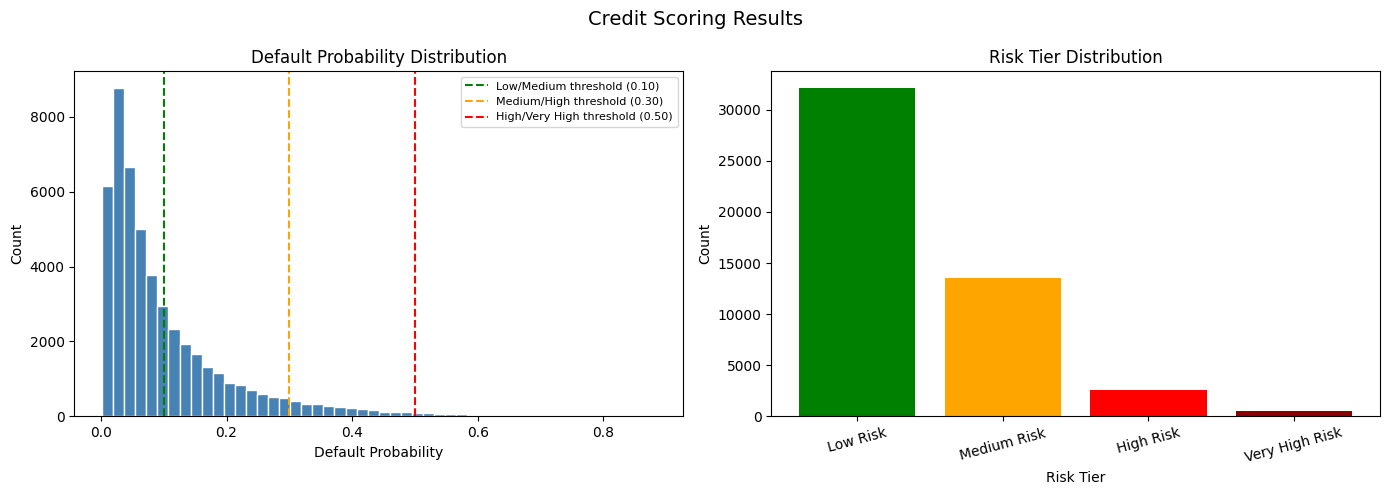

In [27]:
# Visualization - probability score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of probability scores
axes[0].hist(y_prob_test, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Default Probability Distribution')
axes[0].set_xlabel('Default Probability')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0.10, color='green', linestyle='--', label='Low/Medium threshold (0.10)')
axes[0].axvline(x=0.30, color='orange', linestyle='--', label='Medium/High threshold (0.30)')
axes[0].axvline(x=0.50, color='red', linestyle='--', label='High/Very High threshold (0.50)')
axes[0].legend(fontsize=8)

# Risk tier bar plot
colors = ['green', 'orange', 'red', 'darkred']
tiers = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
counts = [risk_tier_counts.get(t, 0) for t in tiers]
axes[1].bar(tiers, counts, color=colors)
axes[1].set_title('Risk Tier Distribution')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Credit Scoring Results', fontsize=14)
plt.tight_layout()
plt.show()

### Key Findings - Credit Scoring Results

**Score Distribution**
Default probability scores range from **0.0018** to **0.8828** with a mean of **0.1018** and median of **0.0640**, indicating a right-skewed distribution consistent with the low default rate observed in training data (8.07%).

**Risk Tier Distribution**
- **Low Risk (< 0.10)**: 32,157 applicants (65.97%) — recommended for loan approval with standard terms
- **Medium Risk (0.10 - 0.30)**: 13,553 applicants (27.80%) — recommended for approval with enhanced monitoring or adjusted terms
- **High Risk (0.30 - 0.50)**: 2,546 applicants (5.22%) — recommended for stricter evaluation or reduced loan principal
- **Very High Risk (> 0.50)**: 488 applicants (1.00%) — recommended for rejection or requiring additional collateral

**Business Implication**
Approximately **34.02%** of applicants (16,587) fall into Medium Risk or above categories, suggesting the model identifies a meaningful subset of applicants requiring additional scrutiny before loan approval.

# 3. Export Results

This section compiles the final credit scoring results and exports them for business use. The output includes applicant ID, default probability score, and assigned risk tier.

In [28]:
# Compile final results
df_results = pd.DataFrame({
    'SK_ID_CURR': sk_id_curr.values,
    'DEFAULT_PROBABILITY': y_prob_test.round(4),
    'RISK_TIER': risk_tiers
})

# Add risk tier numeric for sorting
risk_tier_map = {
    'Low Risk': 1,
    'Medium Risk': 2,
    'High Risk': 3,
    'Very High Risk': 4
}
df_results['RISK_TIER_NUM'] = df_results['RISK_TIER'].map(risk_tier_map)

# Sort by default probability descending
df_results = df_results.sort_values('DEFAULT_PROBABILITY', ascending=False).reset_index(drop=True)

print(f"Final results shape: {df_results.shape}")
print(f"\nSample results (Top 10 highest risk):")
print(df_results.head(10))

Final results shape: (48744, 4)

Sample results (Top 10 highest risk):
   SK_ID_CURR  DEFAULT_PROBABILITY       RISK_TIER  RISK_TIER_NUM
0      297252               0.8828  Very High Risk              4
1      114283               0.8383  Very High Risk              4
2      381164               0.8219  Very High Risk              4
3      265895               0.8057  Very High Risk              4
4      132358               0.7925  Very High Risk              4
5      431543               0.7924  Very High Risk              4
6      324620               0.7922  Very High Risk              4
7      201262               0.7884  Very High Risk              4
8      104410               0.7854  Very High Risk              4
9      184226               0.7824  Very High Risk              4


In [29]:
# Summary statistics per risk tier
print("Summary Statistics per Risk Tier:")
print(df_results.groupby('RISK_TIER')['DEFAULT_PROBABILITY'].agg(['count', 'mean', 'min', 'max']).round(4))

Summary Statistics per Risk Tier:
                count    mean     min     max
RISK_TIER                                    
High Risk        2546  0.3762  0.3000  0.4999
Low Risk        32157  0.0441  0.0018  0.1000
Medium Risk     13553  0.1698  0.1000  0.3000
Very High Risk    488  0.5772  0.5003  0.8828


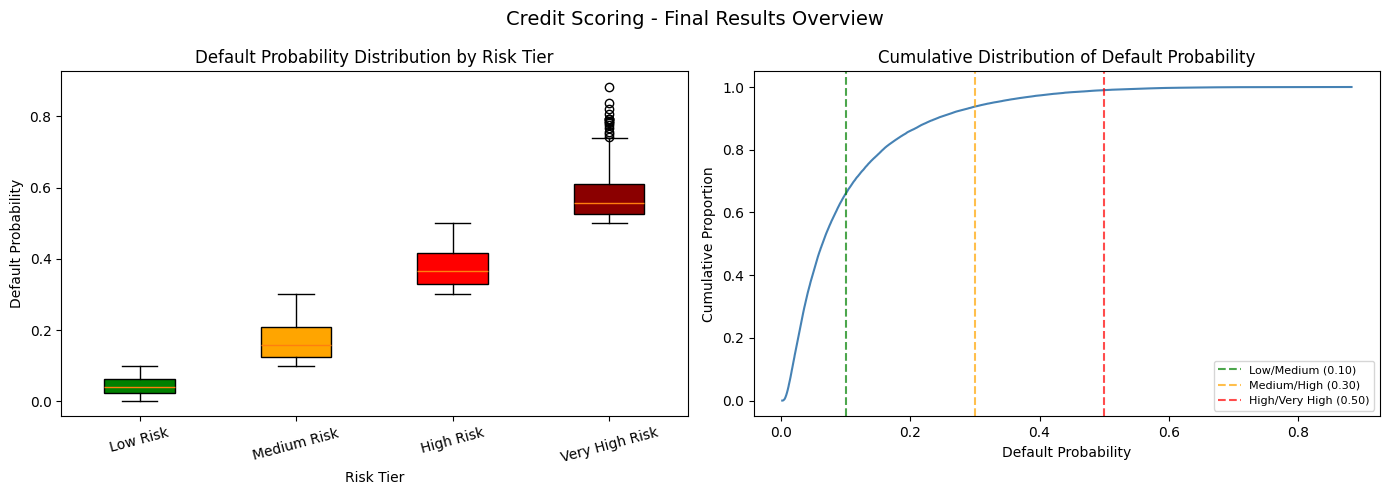

In [30]:
# Visualization - final results overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default probability by risk tier boxplot
colors = {'Low Risk': 'green', 'Medium Risk': 'orange',
          'High Risk': 'red', 'Very High Risk': 'darkred'}
tier_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']

data_by_tier = [df_results[df_results['RISK_TIER'] == tier]['DEFAULT_PROBABILITY'].values
                for tier in tier_order]
bp = axes[0].boxplot(data_by_tier, labels=tier_order, patch_artist=True)
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(colors[tier])
axes[0].set_title('Default Probability Distribution by Risk Tier')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Default Probability')
axes[0].tick_params(axis='x', rotation=15)

# Cumulative distribution of scores
sorted_probs = np.sort(y_prob_test)
cumulative = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)
axes[1].plot(sorted_probs, cumulative, color='steelblue')
axes[1].axvline(x=0.10, color='green', linestyle='--', alpha=0.7, label='Low/Medium (0.10)')
axes[1].axvline(x=0.30, color='orange', linestyle='--', alpha=0.7, label='Medium/High (0.30)')
axes[1].axvline(x=0.50, color='red', linestyle='--', alpha=0.7, label='High/Very High (0.50)')
axes[1].set_title('Cumulative Distribution of Default Probability')
axes[1].set_xlabel('Default Probability')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].legend(fontsize=8)

plt.suptitle('Credit Scoring - Final Results Overview', fontsize=14)
plt.tight_layout()
plt.show()

### Key Findings - Export Results

**Final Output**
Credit scoring results successfully generated for **48,744 applicants** with default probability scores ranging from 0.0018 to 0.8828.

**Risk Tier Summary**
| Risk Tier | Count | Percentage | Avg Probability | Min | Max |
|---|---|---|---|---|---|
| Low Risk | 32,157 | 65.97% | 0.0441 | 0.0018 | 0.1000 |
| Medium Risk | 13,553 | 27.80% | 0.1698 | 0.1000 | 0.3000 |
| High Risk | 2,546 | 5.22% | 0.3762 | 0.3000 | 0.4999 |
| Very High Risk | 488 | 1.00% | 0.5772 | 0.5003 | 0.8828 |

**Highest Risk Applicants**
The top highest risk applicant (`SK_ID_CURR = 297252`) has a default probability of **0.8828**, indicating extremely high likelihood of default. The top 10 highest risk applicants all show probabilities above 0.78, warranting immediate rejection or additional collateral requirements.

**Score Distribution Interpretation**
The cumulative distribution confirms that approximately 66% of applicants fall below the 0.10 threshold, 94% below 0.30, and 99% below 0.50. This distribution is consistent with the low default rate observed in training data and reflects a realistic credit risk portfolio.

**Business Action by Risk Tier:**
- **Low Risk**: Approve with standard loan terms
- **Medium Risk**: Approve with enhanced monitoring or adjusted repayment schedule
- **High Risk**: Require additional documentation, reduce principal, or increase collateral
- **Very High Risk**: Reject application or require substantial collateral and co-signer

**Results saved to** `credit_scoring_results.csv`

---

In [31]:
# Export results
output_path = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\credit_scoring_results.csv'
df_results.to_csv(output_path, index=False)

print(f"Credit scoring results saved successfully!")
print(f"Path: {output_path}")
print(f"Total applicants scored: {len(df_results):,}")
print(f"\nFinal Risk Tier Summary:")
for tier in tier_order:
    count = len(df_results[df_results['RISK_TIER'] == tier])
    pct = count / len(df_results) * 100
    print(f"  {tier:<20}: {count:,} ({pct:.2f}%)")

Credit scoring results saved successfully!
Path: D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\credit_scoring_results.csv
Total applicants scored: 48,744

Final Risk Tier Summary:
  Low Risk            : 32,157 (65.97%)
  Medium Risk         : 13,553 (27.80%)
  High Risk           : 2,546 (5.22%)
  Very High Risk      : 488 (1.00%)


In [1]:
# Read markdown cells from notebook
import json

with open('Credit_Scoring.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'markdown':
        print(f"--- Cell {i} ---")
        print(''.join(cell['source']))
        print()

--- Cell 0 ---
# Credit Scoring
## Home Credit Default Risk

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/  
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This notebook applies the trained LightGBM Tuned model from `Scorecard_Modelling.ipynb` to generate credit scores for new loan applicants in `application_test.csv`. The same preprocessing pipeline used during model training is applied to ensure consistency between training and scoring.

---

## 🎯 Objectives
- Load and preprocess `application_test.csv` using the same pipeline as training data
- Generate default probability scores for each applicant
- Assign risk tiers based on probability thresholds
- Export the final credit scoring results

---

## 🔍 Analysis Scope
The approach includes:
- Loading all raw test datasets and applying the same aggregation pipeline
- Merging all supplementary tables to the test main table
- Applying the same cleanin